<a href="https://colab.research.google.com/github/Zografska/page-rank-arxiv/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PageRank Project - Ranking similarity between papers
### **Student: Aleksandra Zografska (48924A)**
### **Subject: Algorithms for Massive Datasets**
### **Course: Data Science for Economics**


#### 0. Prep environment
- Download Spark
- Align cloudpickle version that caused errors
- Import Spark into notebook

In [1]:
!apt-get update -qq
!apt-get install openjdk-8-jdk-headless
!wget -q http://archive.apache.org/dist/spark/spark-3.1.1/spark-3.1.1-bin-hadoop3.2.tgz
!tar xf spark-3.1.1-bin-hadoop3.2.tgz
!pip install -q findspark

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.1.1-bin-hadoop3.2"

!pip install cloudpickle==2.2.0

import cloudpickle, shutil, os

new_cp_path = os.path.dirname(cloudpickle.__file__)
pyspark_cp_path = "/content/spark-3.1.1-bin-hadoop3.2/python/pyspark/cloudpickle"

print("Replacing:", pyspark_cp_path)
print("With:", new_cp_path)

shutil.copytree(new_cp_path, pyspark_cp_path, dirs_exist_ok=True)

print("Done!")

import findspark
findspark.init()
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()
spark.conf.set("spark.sql.repl.eagerEval.enabled", True) # Property used to format output tables better

sc = spark.sparkContext


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libxtst6 openjdk-8-jre-headless
Suggested packages:
  openjdk-8-demo openjdk-8-source libnss-mdns fonts-dejavu-extra fonts-nanum
  fonts-ipafont-gothic fonts-ipafont-mincho fonts-wqy-microhei
  fonts-wqy-zenhei fonts-indic
The following NEW packages will be installed:
  libxtst6 openjdk-8-jdk-headless openjdk-8-jre-headless
0 upgraded, 3 newly installed, 0 to remove and 137 not upgraded.
Need to get 39.7 MB of archives.
After this operation, 144 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libxtst6 amd64 2:1.2.3-1build4 [13.4 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 op


#### 1. Download and Load Dataset into memory
Using https://www.kaggle.com/datasets/Cornell-University/arxiv

In [2]:
import os
os.environ['KAGGLE_USERNAME'] = "XX"
os.environ['KAGGLE_KEY'] = "XX"
!kaggle datasets download -d Cornell-University/arxiv


Dataset URL: https://www.kaggle.com/datasets/Cornell-University/arxiv
License(s): CC0-1.0
 97% 1.54G/1.59G [00:10<00:01, 42.4MB/s]
100% 1.59G/1.59G [00:10<00:00, 159MB/s] 


In [3]:
import zipfile

with zipfile.ZipFile("arxiv.zip", "r") as zip_ref:
    zip_ref.extractall("arxiv_data")

A regular json read didn't suffice. Session crached because of using too much ram, we need to load it by chunks.





Tunnel the SparkUI dashboard.
Since we're running on a remote machine, the local link of the Spark dashboard is not accessible.

In [4]:
!pip install pyngrok -q
from pyngrok import ngrok

ngrok.set_auth_token("30gF0FlmDEauBmvimUqmod1orzn_5biy1oHisrWFT9Nsc6iW6")
# Open a tunnel to Spark UI port 4040
tunnel = ngrok.connect(4040)
print(f"Spark UI: {tunnel.public_url}")

Spark UI: https://a254-34-82-157-235.ngrok-free.app


Using this block whenever I cancel an execution. Otherwise jobs sometimes get stuck, and memory occupation piles up.
Unncomment to use...

In [5]:
# # Unpersist any cached DataFrames/RDDs
spark.catalog.clearCache()
# # kill the previous jobs (of keyboard interrupted code executions) since they
# # are blocking the job queuex
sc.cancelAllJobs()



Since the Dataset is really big, and with my current algorithm it took 14 hours to create the pages and links, I decided to use sampling to get a smaller subsample and filtering to get a more meaningfull graph.

In [6]:
from itertools import combinations
import json

SUBSAMPLE_FRAC   = 0.1        # 0.n -> n% of lines
CATEGORY_FILTER  = "econ"        # None = all categories, or e.g. "cs", "math", "physics"


raw_rdd = sc.textFile(
    "arxiv_data/arxiv-metadata-oai-snapshot.json",
    minPartitions=8
)


raw_rdd = raw_rdd.sample(withReplacement=False, fraction=SUBSAMPLE_FRAC, seed=42)
print(f"Subsampling {SUBSAMPLE_FRAC*100:.1f}% of data")

if CATEGORY_FILTER:
    def matches_category(line):
        try:
            record = json.loads(line)
            cats = record.get("categories", "")
            return any(c.startswith(CATEGORY_FILTER) for c in cats.split())
        except:
            return False

    raw_rdd = raw_rdd.filter(matches_category)
    print(f"Filtering to category: {CATEGORY_FILTER}")


n_papers = raw_rdd.count()
print(f"Processing {n_papers} papers")

Subsampling 10.0% of data
Filtering to category: econ
Processing 1500 papers


In [7]:
n_partitions = max(8, n_papers // 50_000)
print("ok")

def extract_names(line):
    try:
        record = json.loads(line)
        authors = record.get("authors_parsed", [])
        print(authors)
        return [" ".join(part for part in a if part).strip() for a in authors]
    except:
        return []

name_to_idx = (raw_rdd
    .flatMap(extract_names)
    .distinct()
    .zipWithIndex()
    .collectAsMap()
)
idx_broadcast = sc.broadcast(name_to_idx)
print(f"Index built: {len(name_to_idx)} authors")

def extract_pairs(line):
    try:
        record = json.loads(line)
        authors = record.get("authors_parsed", [])
        names = [" ".join(part for part in a if part).strip() for a in authors]

        idx = idx_broadcast.value
        pairs = set()
        for a, b in combinations(names, 2):
            ia, ib = idx.get(a), idx.get(b)
            if ia is not None and ib is not None:
                pairs.add((ia, ib))
                pairs.add((ib, ia))
        return list(pairs)
    except:
        return []

pairs_rdd = (raw_rdd
    .flatMap(extract_pairs)
    .distinct()
    .repartition(n_partitions)
    .cache()
)

links = pairs_rdd.collect()
pages = list(name_to_idx.keys())
print(f"{len(pages)} authors, {len(links)} links")

ok
Index built: 3349 authors
3349 authors, 9898 links


#### Page Rank: The author that collaborates the most with other authors

In [8]:
import numpy as np
import networkx as nx

def get_connection_matrix(pages, links):
    incidency = {}
    for u in range(len(pages)):
        incidency[u] = []

    for (a, b) in links:
        incidency[a].append(b)

    connection_matrix = []
    for a in incidency:
       for b in incidency[a]:
            connection_matrix.append((b, a, 1./len(incidency[a])))

    return connection_matrix

def get_page_rank(pages, links, tolerance=1e-6, max_iterations=100, partitions=8):
    connection_matrix = get_connection_matrix(pages, links)
    links_RDD = sc.parallelize(connection_matrix, numSlices=partitions).cache()

    print(f"Edges: {len(connection_matrix)}")
    print(f"Nodes: {len(pages)}")

    n = len(pages)
    page_rank = np.ones(n) / n
    d = 0.85
    print("Starting iterations")

    for iteration in range(max_iterations):
        old_page_rank = page_rank
        pr_broadcast = sc.broadcast(page_rank)
        print("starting dict")
        page_rank_dict = (
            links_RDD
            .map(lambda t: (t[0], t[2] * pr_broadcast.value[t[1]]))
            .reduceByKey(lambda a, b: a + b)
            .collectAsMap()
        )
        print("done dict")
        pr_broadcast.unpersist()
        print("done dict unpersist")

        page_rank = np.array([page_rank_dict.get(i, 0.0) for i in range(n)])
        print("done page rank before teleportation")
        page_rank = d * page_rank + (1 - d) / n

        dist = np.abs(old_page_rank - page_rank).sum()
        print(f"Iter {iteration+1}: dist={dist:.2e}")

        if dist < tolerance:
            break

    print(f'{iteration+1} iterations')
    return page_rank

In [9]:
rank = get_page_rank(pages, links, partitions=n_partitions)
# see top authors
ranked = sorted(zip(pages, rank), key=lambda x: -x[1])
for author, score in ranked[:20]:
    print(f"{score:.6f}  {author}")

Edges: 9898
Nodes: 3349
Starting iterations
starting dict
done dict
done dict unpersist
done page rank before teleportation
Iter 1: dist=1.93e-01
starting dict
done dict
done dict unpersist
done page rank before teleportation
Iter 2: dist=5.66e-02
starting dict
done dict
done dict unpersist
done page rank before teleportation
Iter 3: dist=2.91e-02
starting dict
done dict
done dict unpersist
done page rank before teleportation
Iter 4: dist=1.80e-02
starting dict
done dict
done dict unpersist
done page rank before teleportation
Iter 5: dist=1.18e-02
starting dict
done dict
done dict unpersist
done page rank before teleportation
Iter 6: dist=8.32e-03
starting dict
done dict
done dict unpersist
done page rank before teleportation
Iter 7: dist=6.17e-03
starting dict
done dict
done dict unpersist
done page rank before teleportation
Iter 8: dist=4.73e-03
starting dict
done dict
done dict unpersist
done page rank before teleportation
Iter 9: dist=3.75e-03
starting dict
done dict
done dict unpe

#### Visualize Ranks

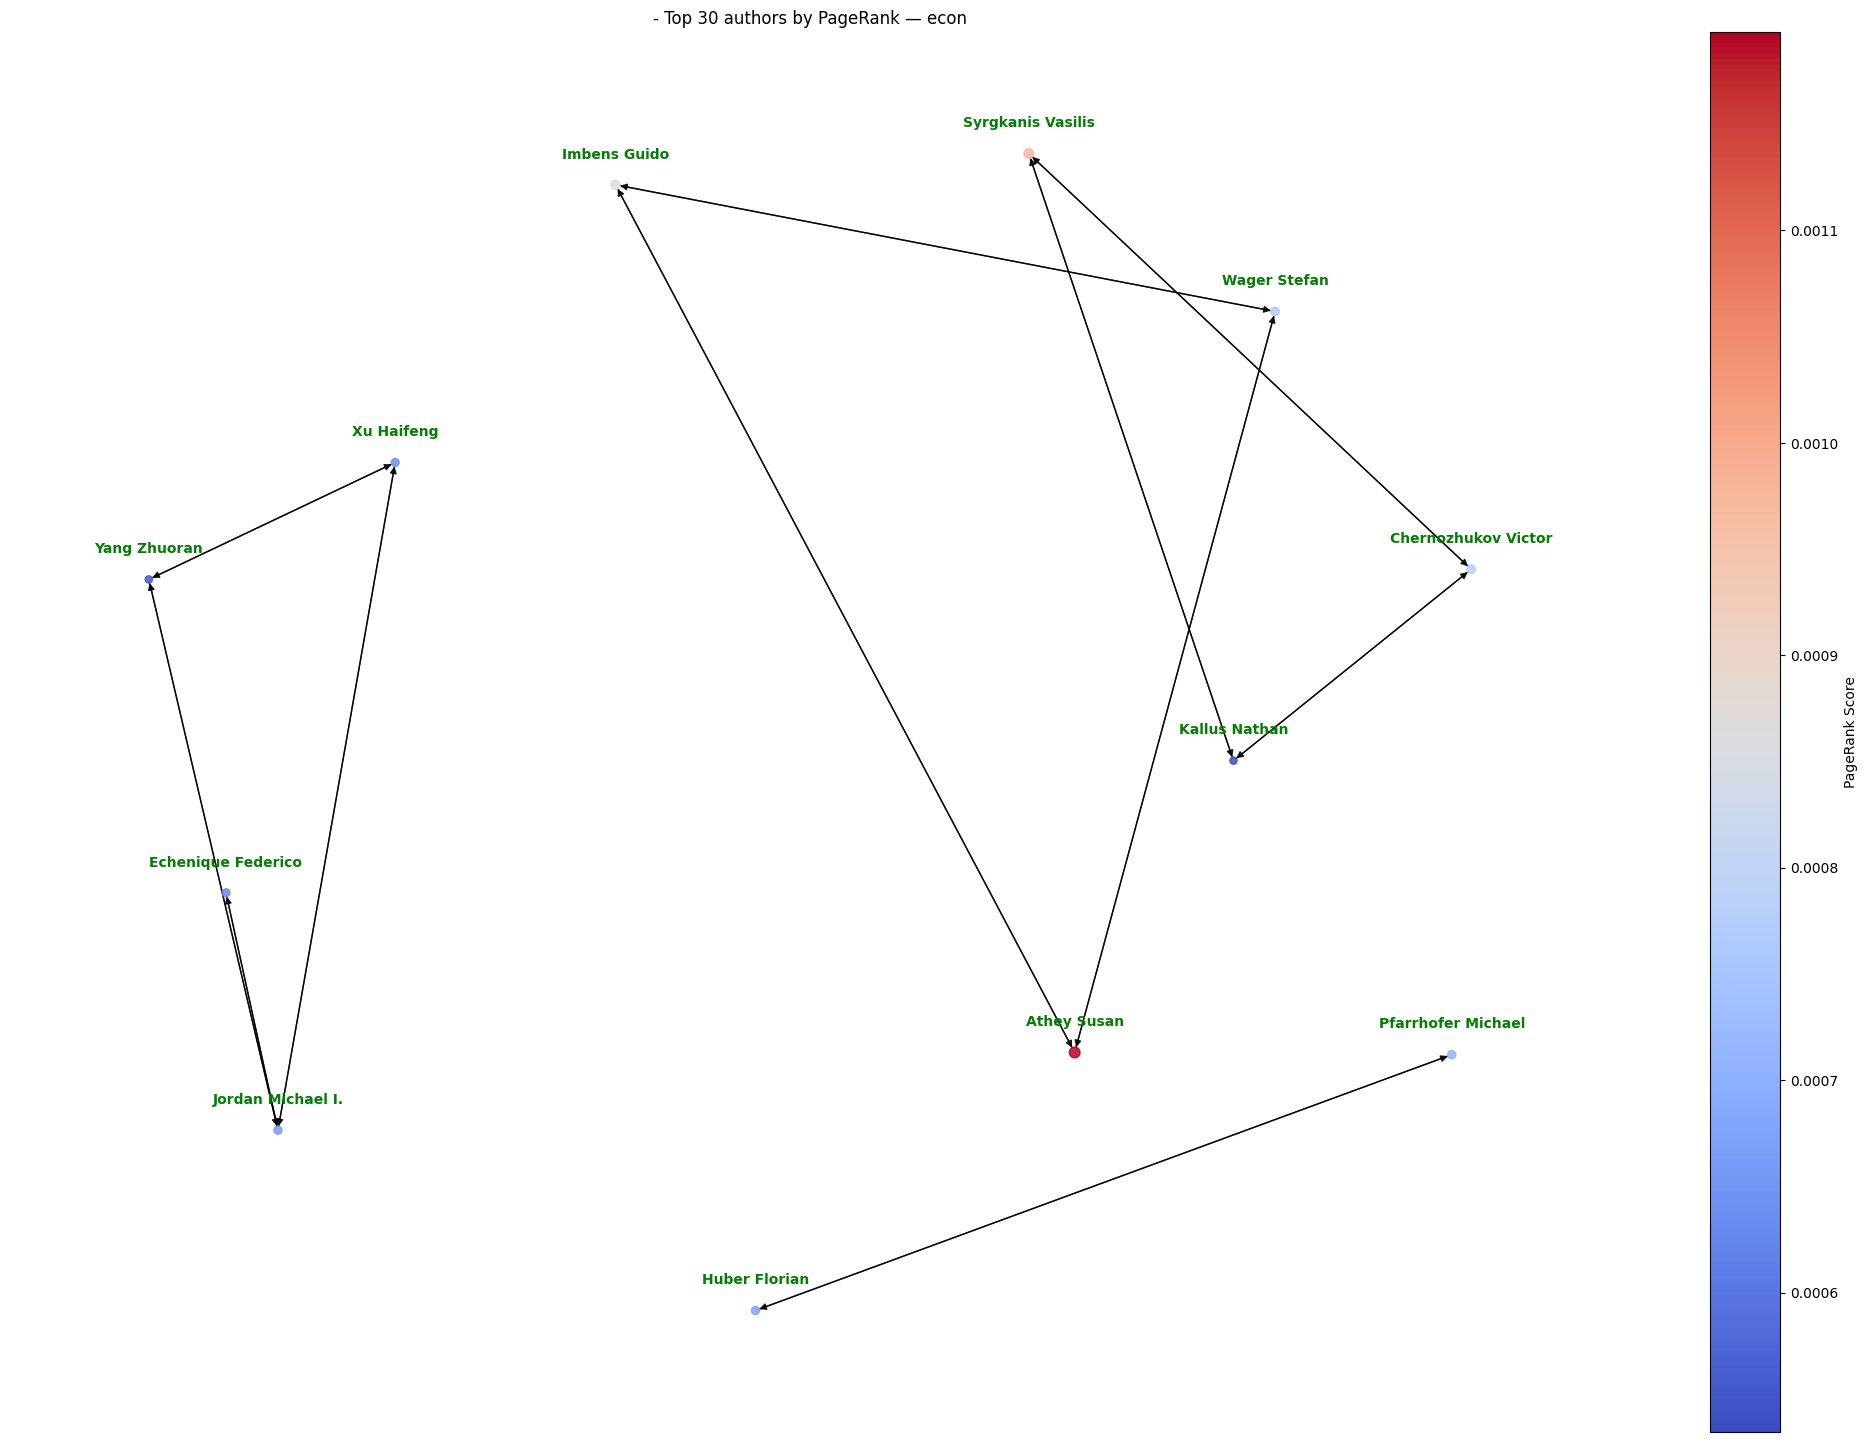

In [10]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Take top N authors by rank
top_n = 30
ranked = sorted(zip(pages, rank), key=lambda x: -x[1])
top_authors = [author for author, _ in ranked[:top_n]]
top_scores = {author: score for author, score in ranked[:top_n]}

# Build subgraph
top_set = set(top_authors)
top_page_index = {name: i for i, name in enumerate(top_authors)}

top_links = [(top_page_index[pages[a]], top_page_index[pages[b]])
             for a, b in links
             if pages[a] in top_set and pages[b] in top_set]

g = nx.DiGraph([(top_authors[a], top_authors[b]) for a, b in top_links])

pos = nx.spring_layout(g, seed=42, k=2)  # k controls spacing
node_colors = [top_scores[author] for author in g.nodes()]
node_sizes  = [top_scores[author] * 50000 for author in g.nodes()]
page_labels = {author: author for author in g.nodes()}

# Plot
plt.figure(figsize=(20, 14))
nx.draw(g, pos=pos, node_color=node_colors, cmap=plt.cm.coolwarm,
        node_size=node_sizes, alpha=0.85, with_labels=False)

# Draw labels with a vertical offset so they sit above the nodes
offset_pos = {node: (x, y + 0.05) for node, (x, y) in pos.items()}
nx.draw_networkx_labels(g, offset_pos, labels=page_labels, font_size=10, font_color="green", font_weight="bold")

sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm,
     norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
plt.colorbar(sm, ax=plt.gca(), label="PageRank Score") # passing ax=plt.gca() to give the colorbar an axes to attatch to
plt.title(f"- Top {top_n} authors by PageRank — {CATEGORY_FILTER}")
plt.show()